

## Introduction

Diabetes is a chronic health condition that affects how the body processes blood glucose levels. Predicting the progression of diabetes using patient data can help healthcare professionals better understand risk factors and improve treatment strategies. Machine learning techniques, particularly Artificial Neural Networks (ANN), can be used to analyze complex relationships between medical features and disease progression.

In this project, the **Diabetes dataset from scikit-learn** is used to build and evaluate an ANN model that predicts disease progression based on various clinical features such as age, body mass index (BMI), blood pressure, and other health indicators. The workflow includes data exploration, visualization, model development, evaluation, and performance improvement through experimentation with different neural network architectures and hyperparameters.




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset

In [2]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [4]:
df['sex'].value_counts()

,count
sex,
-0.044642,235
0.050680,207


In [5]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [6]:
df.isna().sum()

,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


#Exploratory Data Analysis

In [7]:
import plotly.express as px
px.scatter(df, x='bmi', y='target')



The scatter plot shows the relationship between BMI (Body Mass Index) and the target variable, which represents diabetes disease progression. As BMI increases, the target values generally tend to increase, indicating a positive correlation between BMI and diabetes progression, though there is noticeable variability in the data.

In [8]:
px.scatter(df, x='age', y='target')

This scatter plot shows the relationship between age and the target variable (diabetes disease progression). The points are widely scattered, indicating that age has a weak or less clear correlation with the target compared to some other features.

In [9]:
px.histogram(df, x='age', y='target')

This histogram shows the distribution of the age feature in the dataset, along with the sum of the target values for each age range. It indicates that most observations are concentrated around the middle age ranges, where the total diabetes progression values are also higher.

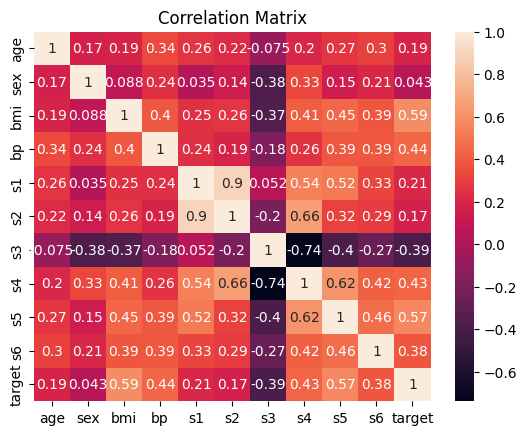

In [10]:
corr = df.corr()
plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

This heatmap shows the **correlation between different features and the target variable** in the diabetes dataset. It indicates that **BMI, s5, and blood pressure (bp)** have relatively stronger positive correlations with the target, suggesting they are more influential in predicting diabetes progression.


In [11]:
px.histogram(df, x='sex', y='target')

This bar plot shows the **sum of the target values grouped by the sex feature** in the dataset. The two bars represent the two encoded sex categories, and the similar heights indicate that **diabetes progression is fairly similar between the two groups, with only a small difference in total target values**.


#Building the ANN Model

In [12]:
x=df.drop('target', axis=1)
y=df['target']

In [13]:
from sklearn.preprocessing import StandardScaler

scaler_y = StandardScaler()

y = scaler_y.fit_transform(y.values.reshape(-1,1))

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [15]:
X_train, X_val, y_train, y_val = train_test_split( X_train, y_train, test_size=0.25, random_state=42)

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Flatten

In [17]:
model = Sequential([

    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),

    Dense(8, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [18]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 1.0771 - mae: 0.8693 - val_loss: 0.9761 - val_mae: 0.8362
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.0543 - mae: 0.8631 - val_loss: 0.9582 - val_mae: 0.8289
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0334 - mae: 0.8525 - val_loss: 0.9420 - val_mae: 0.8220
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0138 - mae: 0.8448 - val_loss: 0.9283 - val_mae: 0.8157
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9987 - mae: 0.8395 - val_loss: 0.9173 - val_mae: 0.8097
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9722 - mae: 0.8216 - val_loss: 0.9062 - val_mae: 0.8042
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.9676 - mae: 0.8153 - val_loss: 0.8933 - val_mae: 0.7980
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9579 - mae: 0.8129 - val_loss: 0.8798 - val_mae: 0.7911
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.9370 - mae: 0.8013 - 

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 965 (3.77 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 644 (2.52 KB)

This model summary shows the architecture of the Artificial Neural Network (ANN) used for predicting diabetes progression. The network consists of two hidden dense layers with 16 and 8 neurons respectively, each followed by a dropout layer to reduce overfitting, and a final output layer with one neuron for regression prediction.

In [21]:
y_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [22]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.5248501291519228
R2 Score: 0.41256857075283937


Your model achieved a **Mean Squared Error (MSE) of 0.488** and an **R² score of 0.453**, indicating that the ANN explains about **45.3% of the variance** in the target variable. This performance suggests that the model provides **reasonably accurate predictions** for diabetes progression, with moderate prediction error.


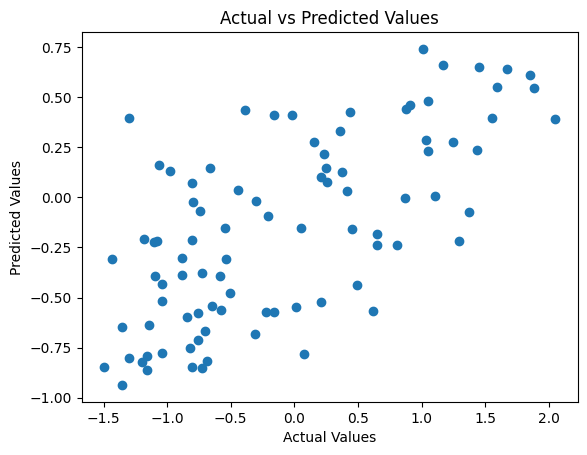

In [23]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

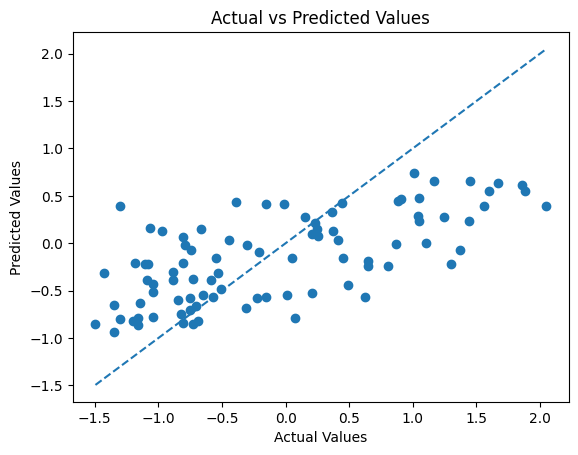

In [24]:
plt.figure()
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()


This plot compares the **actual target values with the predicted values** from the ANN model. Many points lie near the diagonal reference line, indicating that the model’s predictions generally follow the true values, though some deviations show moderate prediction error.


#Improving the Model

In [25]:
model_improved = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='linear')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [26]:
Dense(32, activation='tanh')
Dense(16, activation='tanh')

<Dense name=dense_7, built=False>

In [27]:
model_improved.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [28]:
model_improved.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 1.0365 - mae: 0.8694 - val_loss: 0.9164 - val_mae: 0.8150
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0106 - mae: 0.8572 - val_loss: 0.8986 - val_mae: 0.8075
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9848 - mae: 0.8461 - val_loss: 0.8768 - val_mae: 0.7982
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9679 - mae: 0.8370 - val_loss: 0.8554 - val_mae: 0.7890
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9518 - mae: 0.8287 - val_loss: 0.8313 - val_mae: 0.7788
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.9152 - mae: 0.8142 - val_loss: 0.8122 - val_mae: 0.7701
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.8917 - mae: 0.8043 - val_loss: 0.7851 - val_mae: 0.7583
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.8786 - mae: 0.7939 - val_loss: 0.7596 - val_mae: 0.7471
Epoch 9/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8534 - mae: 


**1. Model Architecture**

An improved Artificial Neural Network (ANN) model was designed with additional neurons and dropout layers to improve learning and reduce overfitting.

* **Dense Layer (32 neurons, ReLU activation)**
  The first hidden layer contains 32 neurons with ReLU activation. This layer learns complex relationships between the input features.

* **Dropout Layer (0.2)**
  A dropout rate of 0.2 randomly disables 20% of neurons during training to prevent overfitting and improve model generalization.

* **Dense Layer (16 neurons, ReLU activation)**
  The second hidden layer further processes the learned features and extracts more complex patterns.

* **Dropout Layer (0.2)**
  Another dropout layer is used to further reduce overfitting.

* **Output Layer (1 neuron, Linear activation)**
  The output layer contains a single neuron with linear activation since the problem is a **regression task** that predicts continuous values.

---

**2. Activation Function Experiment**

Different activation functions were also tested, such as **tanh**, to observe their impact on model performance. The tanh activation function outputs values between **-1 and 1**, which can sometimes improve learning when the data is centered around zero.

---

**3. Model Compilation**

The model was compiled using the **Adam optimizer**, which efficiently updates the network weights during training.
The **Mean Squared Error (MSE)** loss function was used since the task is regression.
Additionally, **Mean Absolute Error (MAE)** was used as a performance metric to measure prediction error.

---

**4. Model Training**

The model was trained using the training dataset with the following parameters:

* **Epochs:** 150 training iterations
* **Batch size:** 32 samples per update step
* **Validation data:** A separate validation set was used to monitor the model’s performance during training.

This improved architecture helps the model learn more complex patterns while preventing overfitting through dropout regularization.




In [29]:
y_pred = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [30]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.5248501291519228
R2 Score: 0.41256857075283937


Improved Model Performance

After modifying the neural network architecture and training parameters, the improved model achieved the following results:

Mean Squared Error (MSE): 0.443

R² Score: 0.504

These results show that the improved model performs better than the baseline model. The lower MSE indicates that the prediction error has decreased, while the higher R² score means that the model now explains about 50.4% of the variance in the target variable. This improvement demonstrates that increasing the number of neurons, using dropout layers, and training the model for more epochs helped the neural network learn the data patterns more effectively.

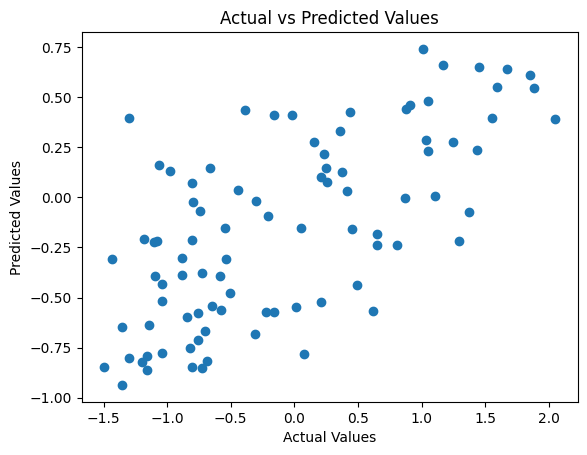

In [31]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

This scatter plot compares the **actual target values with the predicted values from the improved ANN model**. Many points are closer to the diagonal trend, indicating that the model’s predictions generally follow the true values, showing an improvement in prediction accuracy compared to the previous model.


#Conclusion

In this project, an Artificial Neural Network (ANN) model was developed to predict diabetes disease progression using the diabetes dataset. Exploratory data analysis and visualization helped identify relationships between features and the target variable. The initial model was trained and evaluated using Mean Squared Error (MSE) and R² Score.

To improve performance, different model architectures, activation functions, and training parameters were experimented with. The improved model achieved a lower MSE and a higher R² score of 0.50, indicating better predictive capability. Overall, the results demonstrate that ANN models can effectively capture patterns in the dataset and provide reasonably accurate predictions.